# Clustering to discover latent emotions

Starting from HR_data_PC2, I try to identify different clusters with gmm

GMM with K=3

c:\Users\aless\OneDrive\Documenti\Computational data analysis\cda-case-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- EMOTIONAL PROFILE PER CLUSTER (Mean Questionnaire Scores) ---
Emotional_Cluster         0         1         2
Frustrated         2.057471  1.890511  2.193182
upset              1.333333  1.350365  1.352273
hostile            1.045977  1.051095  1.079545
alert              2.103448  2.145985  2.352273
ashamed            1.229885  1.160584  1.306818
inspired           2.183908  2.090275  2.329545
nervous            1.356322  1.343066  1.465909
attentive          2.747126  2.662661  3.011364
afraid             1.057471  1.051470  1.045455
active             2.448276  2.507687  2.727273
determined         2.988506  2.816247  2.988636


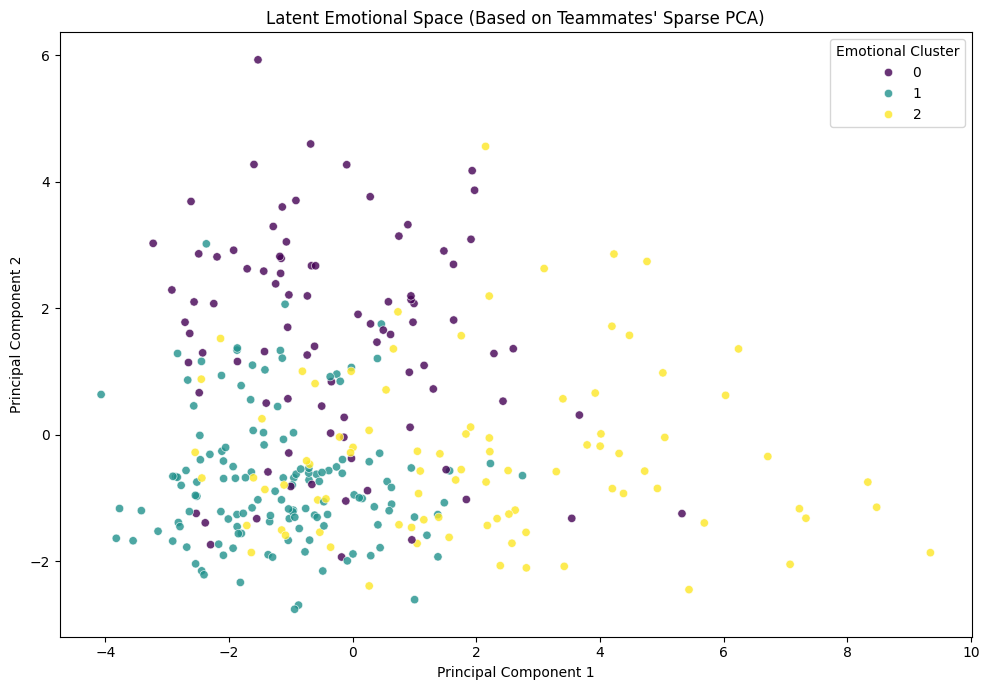


--- Methodological Verification: Phase Distribution ---
Emotional_Cluster   0   1   2
Phase                        
phase1             34  52  18
phase2             24  36  44
phase3             29  49  26


In [1]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import os
from pathlib import Path

base_path = Path(os.getcwd()).resolve().parents[0] 

pca_data_path = base_path / 'data' / 'processed' / 'HR_data_PCA2.csv'
raw_data_path = base_path / 'data' / 'processed' / 'HR_data_2.csv'


df_pca = pd.read_csv(pca_data_path)
df_raw = pd.read_csv(raw_data_path)

# 1. Identify the Principal Components
pc_cols = [c for c in df_pca.columns if c.startswith('PC')]

# 2. GMM CLUSTERING
# We look for 3 latent emotional profiles (K=3)
gmm = GaussianMixture(n_components=3, random_state=42)
df_pca['Emotional_Cluster'] = gmm.fit_predict(df_pca[pc_cols])

# 3. PSYCHOLOGICAL INTERPRETATION
# Map the clusters back to the raw dataset to analyze questionnaire scores
df_raw['Emotional_Cluster'] = df_pca['Emotional_Cluster']

questionnaire_cols = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 
    'nervous', 'attentive', 'afraid', 'active', 'determined'
]

# Calculate the mean score for each emotion within each cluster
emotional_profile = df_raw.groupby('Emotional_Cluster')[questionnaire_cols].mean()

print("\n--- EMOTIONAL PROFILE PER CLUSTER (Mean Questionnaire Scores) ---")
print(emotional_profile.T) 

# 4. VISUALIZATION
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_pca['PC1'], 
    y=df_pca['PC2'], 
    hue=df_pca['Emotional_Cluster'], 
    palette='viridis', 
    alpha=0.8
)
plt.title('Latent Emotional Space (Based on Teammates\' Sparse PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Emotional Cluster')
plt.tight_layout()
plt.show()

# 5. METHODOLOGICAL VERIFICATION
# Check if clusters are still tied to experimental phases (they shouldn't be)
print("\n--- Methodological Verification: Phase Distribution ---")
print(pd.crosstab(df_pca['Phase'], df_pca['Emotional_Cluster']))

We can imagine it to be
* 0: medium intensity
* 1: relaxed
* 2: working flow state

Adding distinction between active puzzlers and instructors


--- EMOTIONAL PROFILE PER CLUSTER (Mean Questionnaire Scores) ---
Emotional_Cluster         0         1         2
Frustrated         2.057471  1.890511  2.193182
upset              1.333333  1.350365  1.352273
hostile            1.045977  1.051095  1.079545
alert              2.103448  2.145985  2.352273
ashamed            1.229885  1.160584  1.306818
inspired           2.183908  2.090275  2.329545
nervous            1.356322  1.343066  1.465909
attentive          2.747126  2.662661  3.011364
afraid             1.057471  1.051470  1.045455
active             2.448276  2.507687  2.727273
determined         2.988506  2.816247  2.988636


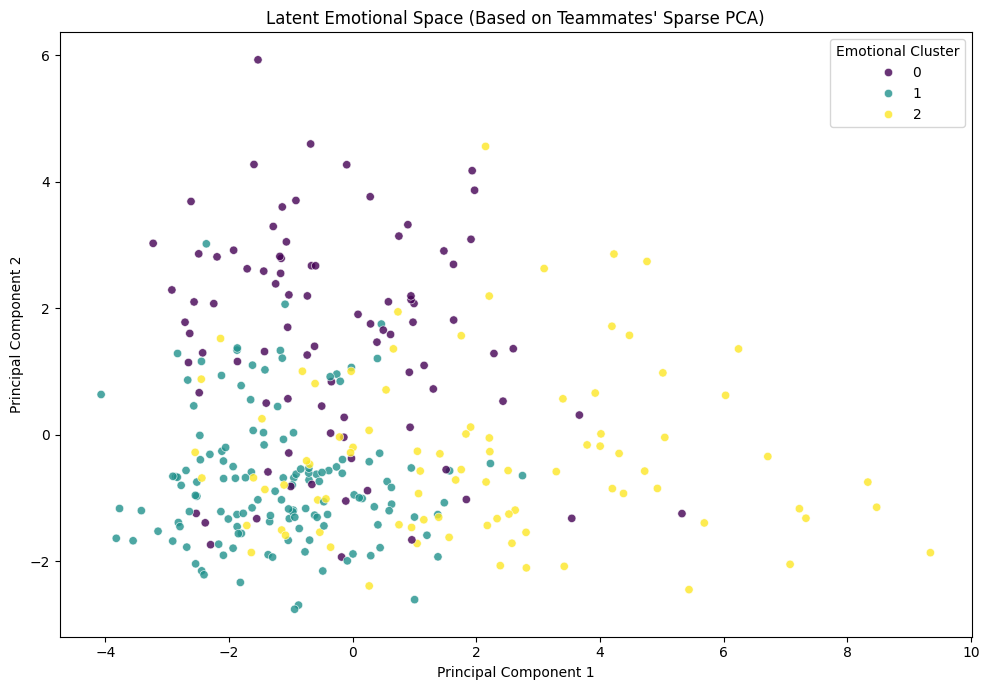


--- Methodological Verification: Phase Distribution ---
Emotional_Cluster   0   1   2
Phase                        
phase1             34  52  18
phase2             24  36  44
phase3             29  49  26

--- Role Verification: Who is in which Emotional State? ---
Emotional_Cluster       0   1   2
Role_Label                       
Instructor (Observer)  41  74  41
Puzzler (Active)       46  63  47

--- Advanced Stratification: Role & Phase vs Emotional Cluster ---
Emotional_Cluster                 0      1      2
Role_Label            Phase                      
Instructor (Observer) phase1  28.85  61.54   9.62
                      phase2  23.08  34.62  42.31
                      phase3  26.92  46.15  26.92
Puzzler (Active)      phase1  36.54  38.46  25.00
                      phase2  23.08  34.62  42.31
                      phase3  28.85  48.08  23.08


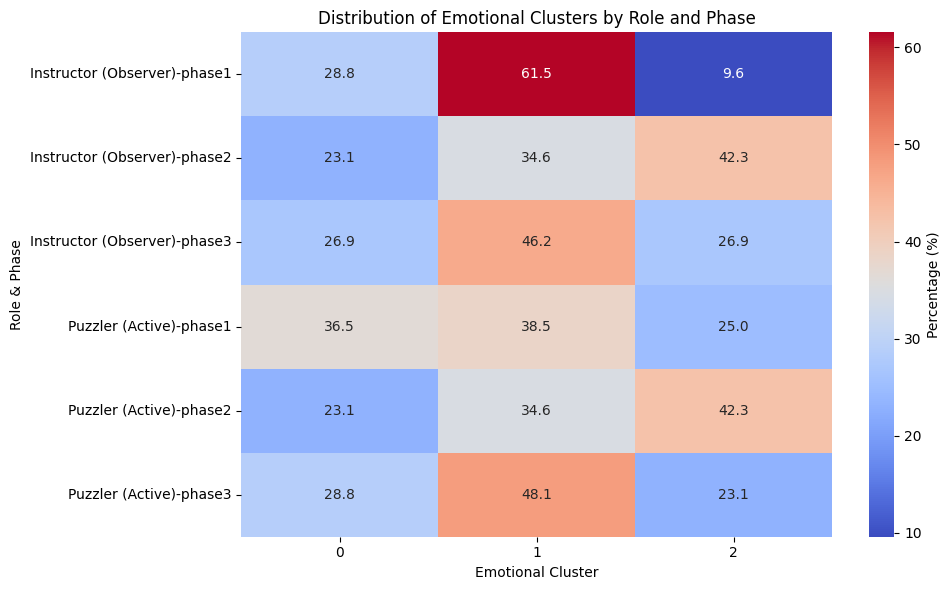

In [2]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import os
from pathlib import Path

# --- CONFIGURATION ---
base_path = Path(os.getcwd()).resolve().parents[0] 
pca_data_path = base_path / 'data' / 'processed' / 'HR_data_PCA2.csv'
raw_data_path = base_path / 'data' / 'processed' / 'HR_data_2.csv'

df_pca = pd.read_csv(pca_data_path)
df_raw = pd.read_csv(raw_data_path)

# 1. Identify the Principal Components
pc_cols = [c for c in df_pca.columns if c.startswith('PC')]

# 2. GMM CLUSTERING
# We look for 3 latent emotional profiles (K=3)
gmm = GaussianMixture(n_components=3, random_state=42)
df_pca['Emotional_Cluster'] = gmm.fit_predict(df_pca[pc_cols])

# 3. PSYCHOLOGICAL INTERPRETATION
df_raw['Emotional_Cluster'] = df_pca['Emotional_Cluster']

questionnaire_cols = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 
    'nervous', 'attentive', 'afraid', 'active', 'determined'
]

emotional_profile = df_raw.groupby('Emotional_Cluster')[questionnaire_cols].mean()

print("\n--- EMOTIONAL PROFILE PER CLUSTER (Mean Questionnaire Scores) ---")
print(emotional_profile.T) 

# 4. VISUALIZATION
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_pca['PC1'], 
    y=df_pca['PC2'], 
    hue=df_pca['Emotional_Cluster'], 
    palette='viridis', 
    alpha=0.8
)
plt.title('Latent Emotional Space (Based on Teammates\' Sparse PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Emotional Cluster')
plt.tight_layout()
plt.show()

# 5. METHODOLOGICAL VERIFICATION (Phases)
print("\n--- Methodological Verification: Phase Distribution ---")
print(pd.crosstab(df_pca['Phase'], df_pca['Emotional_Cluster']))

# 6. ROLE VERIFICATION: Puzzlers vs Instructors (NEW!)
# We check if active players or observers are more prone to certain emotions
print("\n--- Role Verification: Who is in which Emotional State? ---")

# Replace 1 and 0 with readable labels
df_raw['Role_Label'] = df_raw['Puzzler'].replace({1: 'Puzzler (Active)', 0: 'Instructor (Observer)'})

role_crosstab = pd.crosstab(df_raw['Role_Label'], df_raw['Emotional_Cluster'])
print(role_crosstab)
# --- ADVANCED STRATIFICATION: ROLE X PHASE X CLUSTER ---
print("\n--- Advanced Stratification: Role & Phase vs Emotional Cluster ---")

# Ensure we have the role label
df_raw['Role_Label'] = df_raw['Puzzler'].replace({1: 'Puzzler (Active)', 0: 'Instructor (Observer)'})

# Create a multi-index cross-tabulation
# This will result in 6 rows (2 Roles * 3 Phases)
multi_crosstab = pd.crosstab(
    index=[df_raw['Role_Label'], df_raw['Phase']], 
    columns=df_pca['Emotional_Cluster'],
    normalize='index' # Normalizing by row so you see the % distribution
) * 100

print(multi_crosstab.round(2))

# Visualization: Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(multi_crosstab, annot=True, cmap='coolwarm', fmt='.1f', cbar_kws={'label': 'Percentage (%)'})
plt.title('Distribution of Emotional Clusters by Role and Phase')
plt.ylabel('Role & Phase')
plt.xlabel('Emotional Cluster')
plt.tight_layout()
plt.show()

Validation for K=3 or K=2 with BIC

Calculating BIC scores to find the optimal mathematical K...


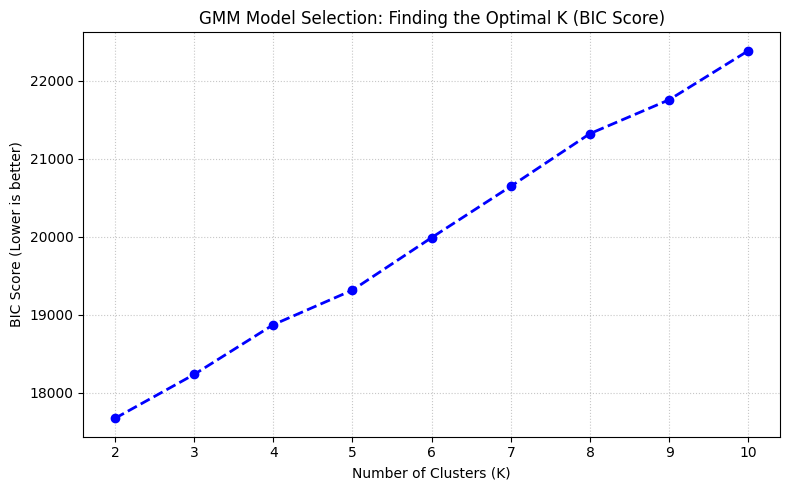


--- CONCLUSION ---
According to the BIC score, the mathematically optimal number of clusters is: K = 2


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import os
from pathlib import Path

# --- CONFIGURATION ---
base_path = Path(os.getcwd()).resolve().parents[0] 
pca_data_path = base_path / 'data' / 'processed' / 'HR_data_PCA2.csv'
df_pca = pd.read_csv(pca_data_path)

# Extract only the Principal Components used by teammates
pc_cols = [c for c in df_pca.columns if c.startswith('PC')]
X = df_pca[pc_cols]

# We will test K from 2 to 10
k_range = range(2, 11)
bic_scores = []

print("Calculating BIC scores to find the optimal mathematical K...")

for k in k_range:
    # Fit a GMM for each value of K
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X)
    # Append the Bayesian Information Criterion score
    bic_scores.append(gmm.bic(X))

# --- PLOT THE RESULTS ---
plt.figure(figsize=(8, 5))
plt.plot(k_range, bic_scores, marker='o', linestyle='--', color='blue', linewidth=2)
plt.title('GMM Model Selection: Finding the Optimal K (BIC Score)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('BIC Score (Lower is better)')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Find and print the best K
best_k = k_range[bic_scores.index(min(bic_scores))]
print(f"\n--- CONCLUSION ---")
print(f"According to the BIC score, the mathematically optimal number of clusters is: K = {best_k}")

Comparison between k=2 and k=3

In [4]:

for k in [2, 3]:
    gmm = GaussianMixture(n_components=k, random_state=42)
    clusters = gmm.fit_predict(df_pca[pc_cols])
    df_raw['Temp_Cluster'] = clusters
    profile = df_raw.groupby('Temp_Cluster')[questionnaire_cols].mean()
    print(f"\n--- Profilo con K={k} ---")
    print(profile.T.head(6)) # Vediamo solo le prime 3 emozioni per brevità


--- Profilo con K=2 ---
Temp_Cluster      0         1
Frustrated    2.208  1.898396
upset         1.416  1.299465
hostile       1.088  1.037433
alert         2.272  2.139037
ashamed       1.296  1.171123
inspired      2.288  2.114266

--- Profilo con K=3 ---
Temp_Cluster         0         1         2
Frustrated    2.057471  1.890511  2.193182
upset         1.333333  1.350365  1.352273
hostile       1.045977  1.051095  1.079545
alert         2.103448  2.145985  2.352273
ashamed       1.229885  1.160584  1.306818
inspired      2.183908  2.090275  2.329545


K=2 is far better

Deep analysis with GMM k=2, split by phases and role


--- EMOTIONAL PROFILE PER CLUSTER (K=2) ---
Emotional_Cluster      0         1
Frustrated         2.208  1.898396
upset              1.416  1.299465
hostile            1.088  1.037433
alert              2.272  2.139037
ashamed            1.296  1.171123
inspired           2.288  2.114266
nervous            1.408  1.363636
attentive          2.960  2.667297
afraid             1.040  1.059099
active             2.696  2.457503
determined         2.992  2.860031


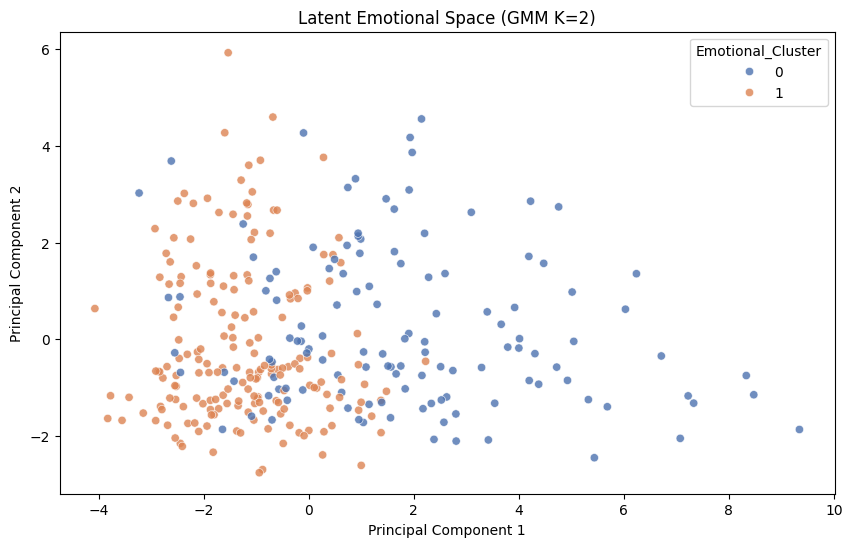

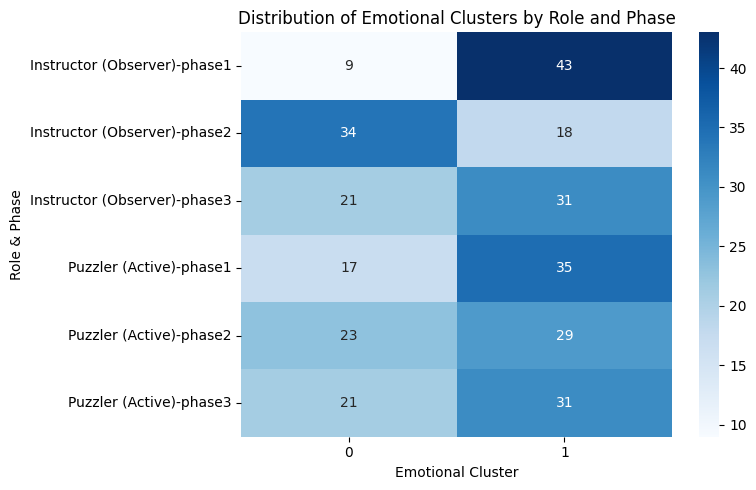


--- Stratified Analysis (Absolute Counts) ---
Emotional_Cluster               0    1  Total
Role_Label            Phase                  
Instructor (Observer) phase1    9   43     52
                      phase2   34   18     52
                      phase3   21   31     52
Puzzler (Active)      phase1   17   35     52
                      phase2   23   29     52
                      phase3   21   31     52
Total                         125  187    312

--- Statistical Summary (Cluster 1) ---
Total subjects in Cluster 1: Phase
    187
Name: 1, dtype: int64
  -> Puzzlers: 95
  -> Instructors: 92

--- Statistical Summary (Cluster 0) ---
Total subjects in Cluster 0: Phase
    125
Name: 0, dtype: int64
  -> Puzzlers: 61
  -> Instructors: 64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from pathlib import Path
import os

# --- 1. CONFIGURATION & LOADING ---
base_path = Path(os.getcwd()).resolve().parents[0] 
pca_data_path = base_path / 'data' / 'processed' / 'HR_data_PCA2.csv'
raw_data_path = base_path / 'data' / 'processed' / 'HR_data_2.csv'

# Load datasets
df_pca = pd.read_csv(pca_data_path)
df_raw = pd.read_csv(raw_data_path)

# --- 2. GMM CLUSTERING (K=2) ---
# We use Principal Components to cluster latent emotional states
pc_cols = [c for c in df_pca.columns if c.startswith('PC')]
gmm = GaussianMixture(n_components=2, random_state=42)

# Assign cluster labels to both dataframes
cluster_labels = gmm.fit_predict(df_pca[pc_cols])
df_pca['Emotional_Cluster'] = cluster_labels
df_raw['Emotional_Cluster'] = cluster_labels

# --- 3. PSYCHOLOGICAL PROFILE (Questionnaire Analysis) ---
questionnaire_cols = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 
    'nervous', 'attentive', 'afraid', 'active', 'determined'
]

emotional_profile = df_raw.groupby('Emotional_Cluster')[questionnaire_cols].mean()
print("\n--- EMOTIONAL PROFILE PER CLUSTER (K=2) ---")
print(emotional_profile.T) 

# --- 4. VISUALIZATION (Latent Space) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_pca['PC1'], y=df_pca['PC2'], 
    hue=df_pca['Emotional_Cluster'], palette='deep', alpha=0.8
)
plt.title('Latent Emotional Space (GMM K=2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# --- 5. ADVANCED STRATIFICATION (Role & Phase Analysis) ---
df_raw['Role_Label'] = df_raw['Puzzler'].replace({1: 'Puzzler (Active)', 0: 'Instructor (Observer)'})

# Crosstab with Totals for statistical reporting
count_crosstab = pd.crosstab(
    index=[df_raw['Role_Label'], df_raw['Phase']], 
    columns=df_raw['Emotional_Cluster'],
    margins=True,
    margins_name='Total'
)


# Heatmap (Excluding 'Total' rows/cols for visual clarity)
plt.figure(figsize=(8, 5))
sns.heatmap(
    count_crosstab.drop('Total', axis=0).drop('Total', axis=1), 
    annot=True, cmap='Blues', fmt='d'
)
plt.title('Distribution of Emotional Clusters by Role and Phase')
plt.ylabel('Role & Phase')
plt.xlabel('Emotional Cluster')
plt.tight_layout()
plt.show()

# --- 6. SUMMARY STATISTICS ---

print("\n--- Stratified Analysis (Absolute Counts) ---")
print(count_crosstab)


total_c1 = count_crosstab.loc['Total', 1]
total_puzzler_c1 = count_crosstab.loc['Puzzler (Active)', 1].sum()
total_instructor_c1 = count_crosstab.loc['Instructor (Observer)', 1].sum()

print(f"\n--- Statistical Summary (Cluster 1) ---")
print(f"Total subjects in Cluster 1: {total_c1}")
print(f"  -> Puzzlers: {total_puzzler_c1}")
print(f"  -> Instructors: {total_instructor_c1}")

print(f"\n--- Statistical Summary (Cluster 0) ---")
total_c0 = count_crosstab.loc['Total', 0]
total_puzzler_c0 = count_crosstab.loc['Puzzler (Active)', 0].sum()
total_instructor_c0 = count_crosstab.loc['Instructor (Observer)', 0].sum()
print(f"Total subjects in Cluster 0: {total_c0}")
print(f"  -> Puzzlers: {total_puzzler_c0}")
print(f"  -> Instructors: {total_instructor_c0}")

Heatmap shows that instructors start from the not stressed state, then they move. There are less changes for the puzzlers 
* 0: stressed
* 1: not stressed

Generating Method 1: Histograms with KDE Overlay & Mean Lines...


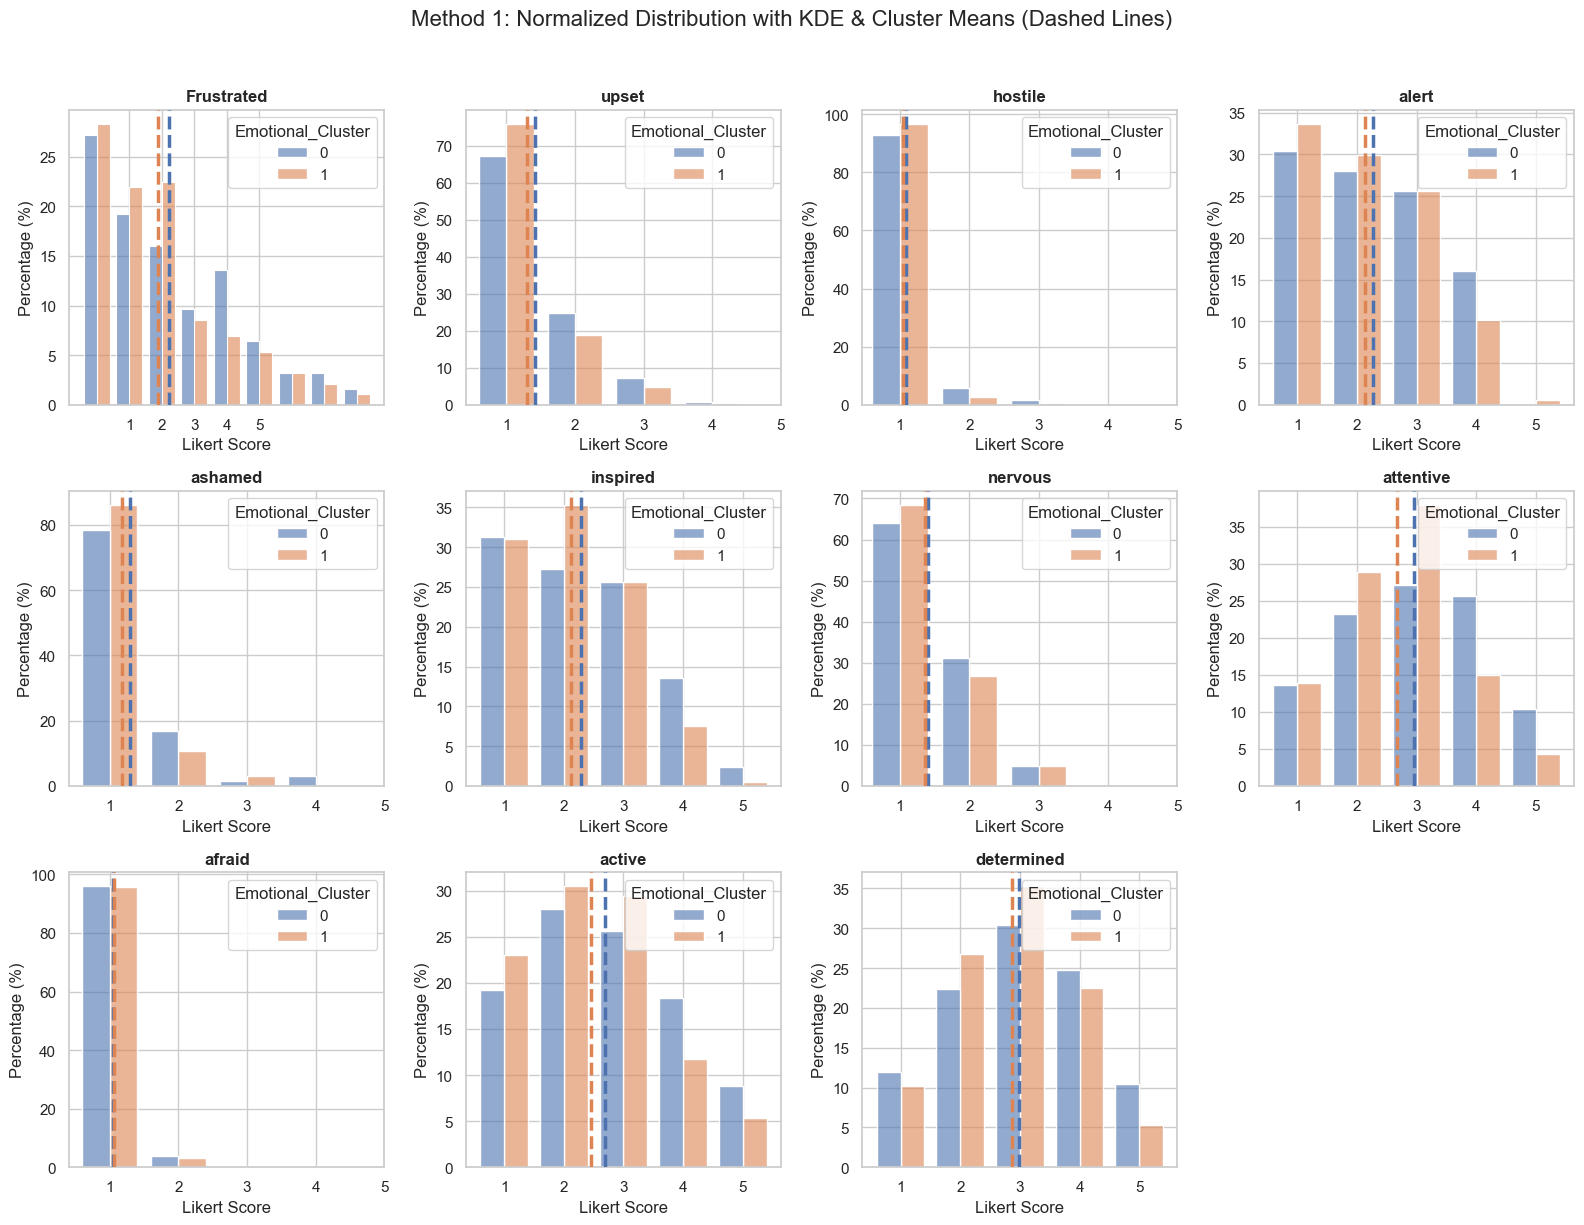

Generating Method 4: Stratified Heatmap...


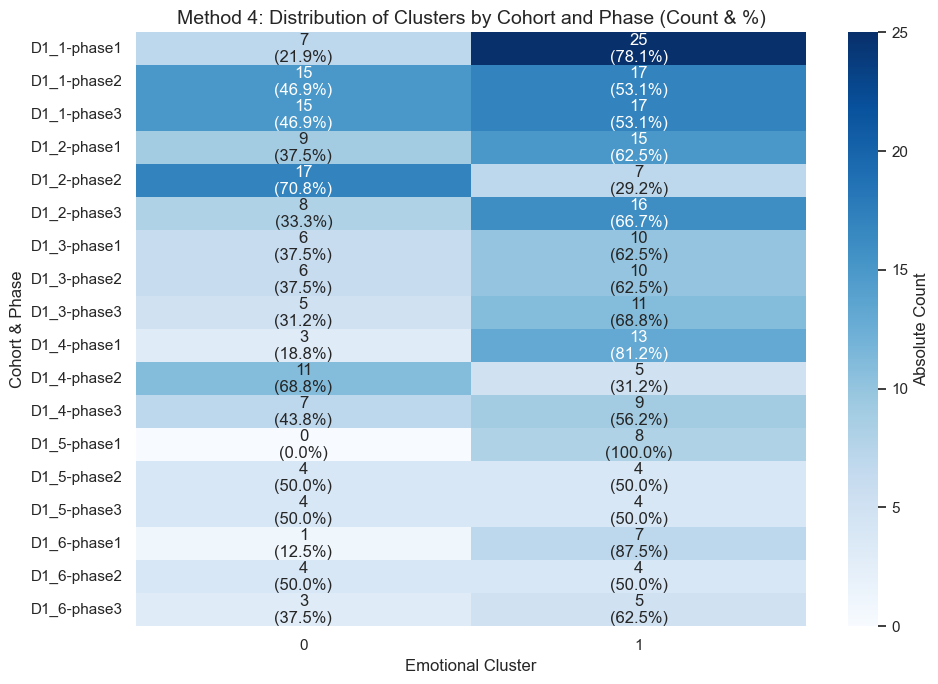

Generating Boxplots by Cluster...


ValueError: The palette dictionary is missing keys: {'0', '1'}

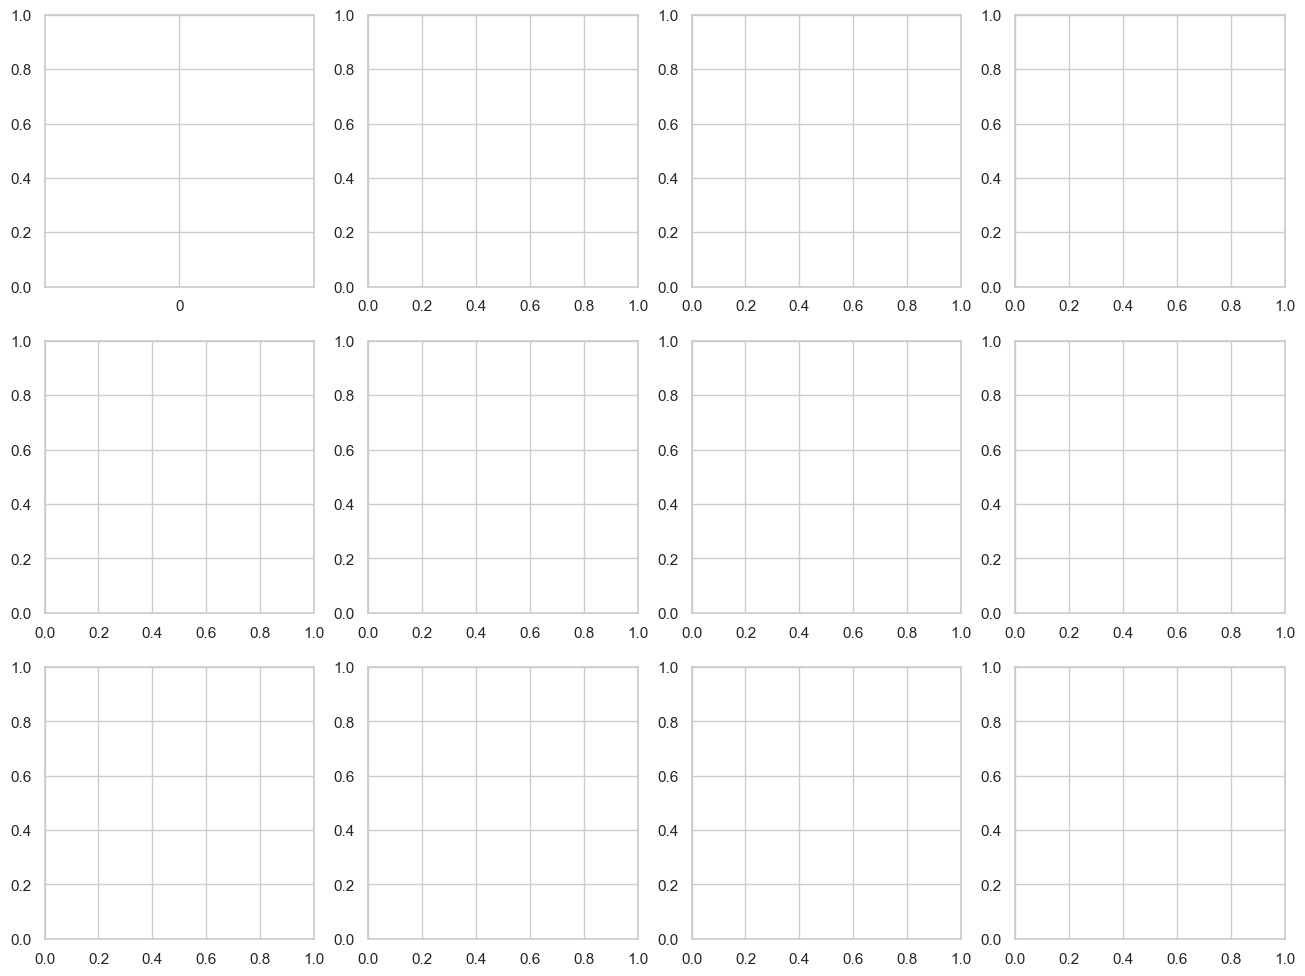

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from math import pi
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# --- 1. SETUP & DATA ---
base_path = Path(os.getcwd()).resolve().parents[0] 
df_pca = pd.read_csv(base_path / 'data' / 'processed' / 'HR_data_PCA2.csv')
df_raw = pd.read_csv(base_path / 'data' / 'processed' / 'HR_data_2.csv')

# --- 2. GMM CLUSTERING (K=2) ---
pc_cols = [c for c in df_pca.columns if c.startswith('PC')]
gmm = GaussianMixture(n_components=2, random_state=42)
df_raw['Emotional_Cluster'] = gmm.fit_predict(df_pca[pc_cols])

questionnaire_cols = [
    'Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 
    'nervous', 'attentive', 'afraid', 'active', 'determined'
]

sns.set_theme(style="whitegrid", palette="muted")

# =====================================================================
# METHOD 1: ENHANCED HISTOGRAMS + KDE + MEAN LINES
# =====================================================================
print("Generating Method 1: Histograms with KDE Overlay & Mean Lines...")
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Definiamo i colori esplicitamente per poter abbinare le linee alle barre
colors = {0: '#4C72B0', 1: '#DD8452'} # Colori standard di Seaborn (Blu e Arancione)

for i, col in enumerate(questionnaire_cols):
    # 1. Usiamo multiple='dodge' per affiancare le barre e non sovrapporle
    sns.histplot(
        data=df_raw, x=col, hue='Emotional_Cluster', 
        multiple='dodge', stat='percent', discrete=True, 
        shrink=0.8, common_norm=False, ax=axes[i],
        palette=colors, alpha=0.6
    )
    
    # 2. Calcoliamo le medie per i due cluster
    mean_c0 = df_raw[df_raw['Emotional_Cluster'] == 0][col].mean()
    mean_c1 = df_raw[df_raw['Emotional_Cluster'] == 1][col].mean()
    
    # 3. Disegniamo le linee tratteggiate verticali
    # zorder=5 assicura che la linea sia disegnata "SOPRA" l'istogramma
    axes[i].axvline(mean_c0, color=colors[0], linestyle='--', linewidth=2.5, zorder=5)
    axes[i].axvline(mean_c1, color=colors[1], linestyle='--', linewidth=2.5, zorder=5)

    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Likert Score')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_xticks([1, 2, 3, 4, 5]) # Forza la visualizzazione di tutti i numeri Likert

axes[-1].set_visible(False)
plt.suptitle('Method 1: Normalized Distribution with KDE & Cluster Means (Dashed Lines)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# =====================================================================
# METHOD 2: STRATIFIED HEATMAP (Counts + %)
# =====================================================================
print("Generating Method 4: Stratified Heatmap...")
counts = pd.crosstab(index=[df_raw['Cohort'], df_raw['Phase']], columns=df_raw['Emotional_Cluster'])
pcts = pd.crosstab(index=[df_raw['Cohort'], df_raw['Phase']], columns=df_raw['Emotional_Cluster'], normalize='index') * 100

annot_matrix = np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(row_c, row_p)] 
                         for row_c, row_p in zip(counts.values, pcts.values)])

plt.figure(figsize=(10, 7))
sns.heatmap(counts, annot=annot_matrix, fmt='', cmap='Blues', cbar_kws={'label': 'Absolute Count'})
plt.title('Method 4: Distribution of Clusters by Cohort and Phase (Count & %)', fontsize=14)
plt.ylabel('Cohort & Phase')
plt.xlabel('Emotional Cluster')
plt.tight_layout()
plt.show()

# =====================================================================
# METHOD: BOXPLOTS (Median, Quartiles, and Outliers)
# =====================================================================


# --- Update the colors dictionary to use string keys ---
colors = {'0': '#4C72B0', '1': '#DD8452'}

# --- Ensure your column is string-typed for consistency ---
df_raw['Emotional_Cluster'] = df_raw['Emotional_Cluster'].astype(str)

for i, col in enumerate(questionnaire_cols):
    sns.boxplot(
        data=df_raw, 
        x='Emotional_Cluster', 
        y=col,
        hue='Emotional_Cluster', # Explicitly set hue to match the x-axis
        palette=colors, 
        width=0.5, 
        ax=axes[i],
        legend=False # Prevents duplicate legends
    )
print("Generating Boxplots by Cluster...")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

# Usiamo i colori standard blu e arancione per coerenza visiva
colors = {0: '#4C72B0', 1: '#DD8452'}

for i, col in enumerate(questionnaire_cols):
    sns.boxplot(
        data=df_raw, 
        x='Emotional_Cluster', 
        y=col,
        palette=colors, 
        width=0.5, # Rende le scatole un po' più eleganti e sottili
        ax=axes[i]
    )
    
    # Formattazione per la pubblicazione
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Likert Score')
    
    # Forza l'asse Y a mostrare solo i valori interi della scala Likert (1-5)
    axes[i].set_yticks([1, 2, 3, 4, 5])
    axes[i].set_ylim(0.5, 5.5) # Aggiunge un po' di respiro sopra e sotto

# Nascondiamo l'ultimo grafico vuoto (essendo 11 emozioni per 12 spazi)
axes[-1].set_visible(False)

plt.suptitle('Emotional Score Distribution by Cluster (Boxplots)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
